---
title: "Longest Collatz Sequence"
subtitle: "Project Euler Problem 14"
author: "Ashish K. Srivastava"
date: "2026-07-12"
description: "The Collatz recurrence, stopping-time conventions, memoization, and a verified solution to Project Euler Problem 14."
categories:
  - Project Euler
  - Number Theory
toc: true
toc-depth: 3
code-fold: show
code-summary: "Hide code"
execute:
  echo: true
  warning: false
  message: false
jupyter: python3
---

The Collatz rule is easy to state, but its long-term behaviour is still not understood. We begin with the rule itself, then use it to solve the finite search problem posed in Project Euler Problem 14.

## The Collatz Process

For a positive integer, apply one of two operations: halve an even number, and replace an odd number by three times the number plus one. Repeating this instruction produces a Collatz sequence, also called an orbit.

Let $\mathbb{N}=\{1,2,3,\ldots\}$. The Collatz map is

$$
T(n)=
\begin{cases}
\dfrac{n}{2}, & \text{if } n \text{ is even},\\[6pt]
3n+1, & \text{if } n \text{ is odd}.
\end{cases}
$$

Starting at $n$, the successive values are $n,T(n),T^2(n),\ldots$. Here $T^k(n)$ means that the map has been applied $k$ times.

## The Collatz Conjecture

The conjecture states that every positive starting value eventually reaches $1$:

$$
\forall n\in\mathbb{N},\quad
\exists k\geq 0
\text{ such that }
T^k(n)=1.
$$

Once the value $1$ is reached, iteration continues around the familiar cycle

$$
1\rightarrow4\rightarrow2\rightarrow1.
$$

For chain lengths, we stop at the first occurrence of $1$.

### Why this is still a conjecture

Large finite ranges have been checked computationally, but a finite computation can verify only finitely many starting values. The conjecture concerns every positive integer.

A proof would have to rule out both an orbit that grows without bound and a non-trivial cycle other than $1\to4\to2\to1$. Neither has been ruled out for all positive integers. The original Collatz conjecture therefore remains a conjecture, not a theorem.

### A first example: $n=13$

Applying the rule carefully gives

$$
13\rightarrow40\rightarrow20\rightarrow10\rightarrow5
\rightarrow16\rightarrow8\rightarrow4\rightarrow2\rightarrow1.
$$

This sequence contains

$$
10\text{ terms}
$$

and takes

$$
9\text{ steps}.
$$

The distinction matters throughout this article:

$$
\text{number of steps}
=
\text{number of terms}-1.
$$

## Generating Collatz Sequences with Python

Before writing a search program, we should be able to generate one orbit correctly. The function below checks that its input is a positive integer and returns the sequence up to the first $1$.

In [1]:
def collatz_sequence(n):
    """Return the Collatz sequence from positive integer n to its first 1."""
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n must be a positive integer")

    sequence = [n]
    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1
        sequence.append(n)
    return sequence


sequence_13 = collatz_sequence(13)
print(sequence_13)
print(f"Terms: {len(sequence_13)}")
print(f"Steps: {len(sequence_13) - 1}")

[13, 40, 20, 10, 5, 16, 8, 4, 2, 1]
Terms: 10
Steps: 9


The output agrees with the hand calculation: $13$ has ten terms and nine steps.

For a few selected values, it is useful to record the chain length and the largest value reached. This is experimental verification of particular cases, not a proof of the conjecture.

In [2]:
def collatz_summary(n):
    """Return basic information about the Collatz sequence starting at n."""
    sequence = collatz_sequence(n)
    return {
        "start": n,
        "terms": len(sequence),
        "steps": len(sequence) - 1,
        "maximum": max(sequence),
    }


test_values = [6, 10, 13, 19, 27, 97]
summaries = [collatz_summary(n) for n in test_values]
for summary in summaries:
    print(summary)

{'start': 6, 'terms': 9, 'steps': 8, 'maximum': 16}
{'start': 10, 'terms': 7, 'steps': 6, 'maximum': 16}
{'start': 13, 'terms': 10, 'steps': 9, 'maximum': 40}
{'start': 19, 'terms': 21, 'steps': 20, 'maximum': 88}
{'start': 27, 'terms': 112, 'steps': 111, 'maximum': 9232}
{'start': 97, 'terms': 119, 'steps': 118, 'maximum': 9232}


| Start | Terms | Steps | Maximum value |
|---:|---:|---:|---:|
| 6 | 9 | 8 | 16 |
| 10 | 7 | 6 | 16 |
| 13 | 10 | 9 | 40 |
| 19 | 21 | 20 | 88 |
| 27 | 112 | 111 | 9232 |
| 97 | 119 | 118 | 9232 |

The chain beginning at $27$ rises as high as $9232$ before returning to $1$; Collatz sequences need not decrease at every step.

In [3]:
sequence_27 = collatz_sequence(27)
print(f"Terms: {len(sequence_27)}")
print(f"Steps: {len(sequence_27) - 1}")
print(f"Maximum value: {max(sequence_27)}")

Terms: 112
Steps: 111
Maximum value: 9232


### Trajectory for $n=27$

A plot makes the rise and fall of this orbit easier to see.

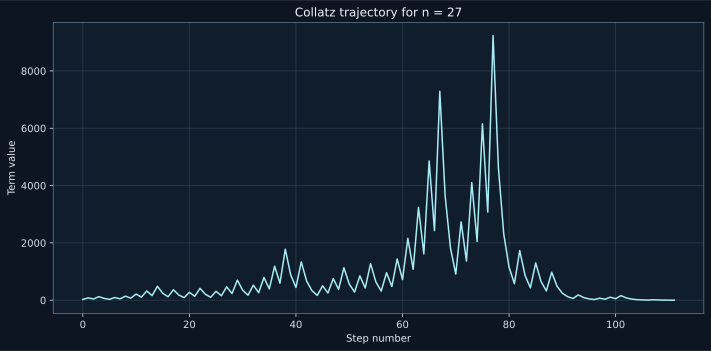

In [4]:
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0c1521")
ax.set_facecolor("#101d2d")
ax.plot(range(len(sequence_27)), sequence_27, linewidth=1.5, color="#a9ecf4")
ax.set_xlabel("Step number", color="#e7edf4")
ax.set_ylabel("Term value", color="#e7edf4")
ax.set_title("Collatz trajectory for n = 27", color="#f1f6fb")
ax.tick_params(colors="#d5e1eb")
for spine in ax.spines.values():
    spine.set_color("#5d7590")
ax.grid(True, color="#7890a8", alpha=0.25)
fig.tight_layout()
plt.show()

## Project Euler Problem 14

The Project Euler question is finite. It asks:

> Among all starting integers satisfying
>
> $$
> 1\leq n<1{,}000{,}000,
> $$
>
> find the starting value that produces the longest Collatz chain before reaching $1$.

Only the starting number must be below one million. Terms later in the chain may be much larger. This is important: the eventual winner rises to more than two billion.

## The Mathematical Structure of the Search

Define

$$
L(n)=\text{number of terms from }n\text{ to the first occurrence of }1.
$$

Then

$$
L(1)=1
$$

and, for $n>1$,

$$
L(n)=1+L(T(n)).
$$

Equivalently,

$$
L(n)=
\begin{cases}
1+L\left(\dfrac{n}{2}\right),
& n\text{ even},\\[8pt]
1+L(3n+1),
& n\text{ odd}.
\end{cases}
$$

Thus the required value is

$$
n_{\max}
=
\operatorname*{arg\,max}_{1\leq n<1{,}000{,}000}L(n).
$$

The key observation is that chains share tails. Once a chain reaches a previously studied value, the remaining work is already known. For example, if $L(10)$ is known, then

$$
L(20)=1+L(10),
$$

$$
L(40)=1+L(20),
$$

and

$$
L(13)=1+L(40).
$$

This recurrence is the reason memoization works. First consider the direct method.

## A Direct Python Solution

The direct method constructs a complete chain for every possible starting value. It is correct, but it repeatedly computes common tails such as $40\to20\to10\to\cdots\to1$.

In [5]:
def longest_collatz_naive(limit):
    """Return the start and term count of the longest chain below limit."""
    if not isinstance(limit, int) or isinstance(limit, bool) or limit <= 1:
        raise ValueError("limit must be an integer greater than 1")

    best_start, best_length = 1, 1
    for n in range(1, limit):
        current_length = len(collatz_sequence(n))
        if current_length > best_length:
            best_start, best_length = n, current_length
    return best_start, best_length


print(longest_collatz_naive(1_000))

(871, 179)


For a small limit this method is adequate. Near one million, the repeated tails become expensive. The recurrence for $L(n)$ tells us what to store.

## Memoization

Start with the known value $L(1)=1$. When a new path reaches a value already stored in a cache, work backwards through the new part of the path. Each predecessor has a chain one term longer than its successor.

In [6]:
def collatz_length(n, cache):
    """Return the term count for n, extending cache along a new tail."""
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n must be a positive integer")

    original_n = n
    path = []
    while n not in cache:
        path.append(n)
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

    known_length = cache[n]
    for value in reversed(path):
        known_length += 1
        cache[value] = known_length
    return cache[original_n]


def longest_collatz(limit):
    """Return the start, term count, and cache for chains below limit."""
    if not isinstance(limit, int) or isinstance(limit, bool) or limit <= 1:
        raise ValueError("limit must be an integer greater than 1")

    cache = {1: 1}
    best_start, best_length = 1, 1
    for n in range(1, limit):
        current_length = collatz_length(n, cache)
        if current_length > best_length:
            best_start, best_length = n, current_length
    return best_start, best_length, cache

The following finite computation solves the Project Euler search. It does not claim to prove the Collatz conjecture.

In [7]:
best_start, best_length, length_cache = longest_collatz(1_000_000)
print(f"Starting number: {best_start}")
print(f"Number of terms: {best_length}")
print(f"Number of steps: {best_length - 1}")

Starting number: 837799
Number of terms: 525
Number of steps: 524


::: {.callout-note}
## Final result

$$
\boxed{837799}
$$

is the starting value below one million with the longest Collatz chain. The chain contains

$$
\boxed{525\text{ terms}}
$$

and requires

$$
\boxed{524\text{ steps}}.
$$
:::

## Inspecting the Winning Sequence

The winning chain eventually enters the familiar tail $40,20,10,5,\ldots,1$.

In [8]:
winning_sequence = collatz_sequence(best_start)
print("First 15 terms:")
print(winning_sequence[:15])
print("\nLast 15 terms:")
print(winning_sequence[-15:])
print(f"\nMaximum value reached: {max(winning_sequence):,}")

First 15 terms:
[837799, 2513398, 1256699, 3770098, 1885049, 5655148, 2827574, 1413787, 4241362, 2120681, 6362044, 3181022, 1590511, 4771534, 2385767]

Last 15 terms:
[70, 35, 106, 53, 160, 80, 40, 20, 10, 5, 16, 8, 4, 2, 1]

Maximum value reached: 2,974,984,576


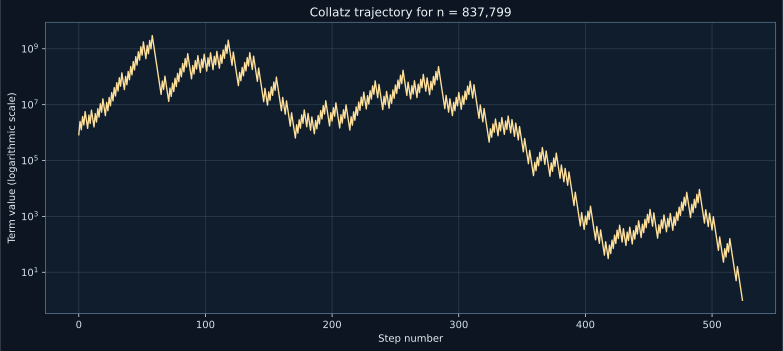

In [9]:
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0c1521")
ax.set_facecolor("#101d2d")
ax.plot(range(len(winning_sequence)), winning_sequence, linewidth=1.35, color="#ffe09a")
ax.set_yscale("log")
ax.set_xlabel("Step number", color="#e7edf4")
ax.set_ylabel("Term value (logarithmic scale)", color="#e7edf4")
ax.set_title("Collatz trajectory for n = 837,799", color="#f1f6fb")
ax.tick_params(colors="#d5e1eb")
for spine in ax.spines.values():
    spine.set_color("#5d7590")
ax.grid(True, color="#7890a8", alpha=0.25)
fig.tight_layout()
plt.show()

The logarithmic vertical scale is necessary here: the chain reaches $2{,}974{,}984{,}576$, far above its starting value.

## Mathematical Ideas Connected with the Collatz Conjecture

The Collatz map is a discrete dynamical system: it studies the long-term behaviour of repeatedly applying a function on the positive integers. Questions about iteration include whether an orbit reaches a cycle, whether it escapes, and how long it takes to fall below its starting value.

The **total stopping time** is

$$
\sigma_\infty(n)=\min\{k\geq0:T^k(n)=1\}.
$$

When the orbit reaches $1$, $L(n)=\sigma_\infty(n)+1$. A related stopping time is the first $k\geq1$ for which $T^k(n)<n$. Proving that every starting value eventually falls below itself would give a route to the conjecture by strong induction, but that statement is also unproved.

For odd $n$, the accelerated Collatz map, often called the Syracuse map, divides all powers of two out of $3n+1$ at once:

$$
S(n)=\frac{3n+1}{2^{\nu_2(3n+1)}}.
$$

Here $\nu_2(m)$ is the exponent of $2$ in $m$. The map sends odd integers directly to odd integers. Parity sequences, or parity vectors, record the even and odd decisions along an orbit. Once a finite parity pattern is fixed, the iterate has an affine form involving powers of $3$ and $2$; the difficulty is that the pattern depends on the orbit itself.

The directed Collatz graph has an arrow $n\longrightarrow T(n)$ from every positive integer. Reversing the arrows produces inverse Collatz trees, which make shared tails visible. Probabilistic heuristics model the powers of two dividing $3n+1$ as if they were random; they help explain the observed downward tendency, but they are not proofs because actual parity events are deterministic and dependent.

Terence Tao proved that for every function $f(N)$ tending to infinity, the minimum value in the orbit of $N$ is at most $f(N)$ for almost all $N$ in the sense of logarithmic density. This does not establish the claim for every starting value. Kurtz and Simon proved an undecidability result for a generalized class of Collatz maps; their theorem does not say that the original Collatz conjecture is undecidable.

## Conclusion

The Collatz conjecture remains open. Project Euler Problem 14 is nevertheless a finite problem, and the recurrence

$$
L(n)=1+L(T(n))
$$

turns its repeated tails into a practical memoized computation. The longest chain below one million starts at $837799$ and has $525$ terms.

## References

1. [Project Euler, Problem 14: Longest Collatz Sequence](https://projecteuler.net/problem=14)
2. Jeffrey C. Lagarias, [The $3x+1$ Problem: An Overview](https://arxiv.org/abs/2111.02635)
3. Terence Tao, [Almost All Orbits of the Collatz Map Attain Almost Bounded Values](https://arxiv.org/abs/1909.03562)
4. Terence Tao, [expository discussion of the result](https://terrytao.wordpress.com/2019/09/10/almost-all-collatz-orbits-attain-almost-bounded-values/)
5. Stuart A. Kurtz and Janos Simon, [The Undecidability of the Generalized Collatz Problem](https://link.springer.com/chapter/10.1007/978-3-540-72504-6_49)